# **Klasifikasi Tweet atau Interaksi Publik terhadap Pilar Astacita Menuju Indonesia Emas 2045**

**Oleh: Heisenberg**



## **1. Problem Understanding**
**Problem Statement**
- Bagaimana cara mengelompokkan tweet ke dalam delapan label yang mewakili pilar Astacita

- Mengatasi kemungkinan ketidakseimbangan kelas yang signifikan dalam dataset, di mana beberapa kategori memiliki data yang jauh lebih sedikit daripada yang lain.

- Sejauh mana model statistik klasik (seperti Random Forest) serta model Transformer dalam mengklasifikan tweet

**Goals**
- Membangun dan mengevaluasi model baseline (TF-IDF + Random Forest).
- Mengembangkan model utama yang robust menggunakan IndoBERT dan Class Weights.

- Membandingkan performa model baseline dengan model utama menggunakan metrik Balanced Accuracy.

- Menghasilkan prediksi final menggunakan model terbaik untuk kompetisi.

## **2. Instalasi dan Impor Library**

In [1]:
!pip -q install transformers datasets scikit-learn emoji imblearn accelerate
!pip install emoji
!pip -q install wordcloud
import os
import pandas as pd
import numpy as np
import re, emoji
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold,train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
import torch
from typing import Dict, Any, List, Optional
from datasets import Dataset
import gc
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud

# Konfigurasi
os.environ["WANDB_DISABLED"] = "True"
print("Semua library berhasil diimpor.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 12.0 MB/s eta 0:00:00
Semua library berhasil diimpor.


### **3. Load Dataset**
Langkah pertama adalah memuat dataset `train.csv` dan `test.csv` ke dalam DataFrame. Kita juga akan melakukan pemeriksaan awal untuk memastikan data dimuat dengan benar dan melihat dimensinya.

In [2]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

print("Data Latih Berhasil Dimuat:")
display(train_df.head())
print("\nData Tes Berhasil Dimuat:")
display(test_df.head())

print(f"\nUkuran Data Latih: {train_df.shape[0]} baris, {train_df.shape[1]} kolom")
print(f"Ukuran Data Tes: {test_df.shape[0]} baris, {test_df.shape[1]} kolom")

Data Latih Berhasil Dimuat:


,text,label
0,@hyalfay @NatharElyas @BosPurwa @NatharElyas @...,ideologi
1,@sienchao @Sherly0ctaviany @jokowi Halo @Sienc...,ideologi
2,@giovannikurnwn @BudiBukanIntel Nama Budi Berl...,ideologi
3,@LeotardosMy @easyanying Kita akui keberhasila...,ideologi
4,@LuckyGaben @susipudjiastuti @prabowo Indonesi...,ideologi



Data Tes Berhasil Dimuat:


,id,text
0,0,@xuminghao_ogf @ShopeeID @ShopeePay_ID Bapak g...
1,1,tidak hanya membayangkan masa depan sebagai ki...
2,2,@feliscxtus Kalau aku jadi pemimpin RI visiku ...
3,3,@EkoDwiSant73293 @Dahnilanzar @prabowo Masyara...
4,4,@goonjol Mengamankan data pribadi rakyat RI si...



Ukuran Data Latih: 5000 baris, 2 kolom
Ukuran Data Tes: 5000 baris, 2 kolom


### **4. Eksplorasi Data Awal (EDA)**
Setelah data dimuat, kita akan melakukan eksplorasi untuk memahami karakteristiknya lebih dalam

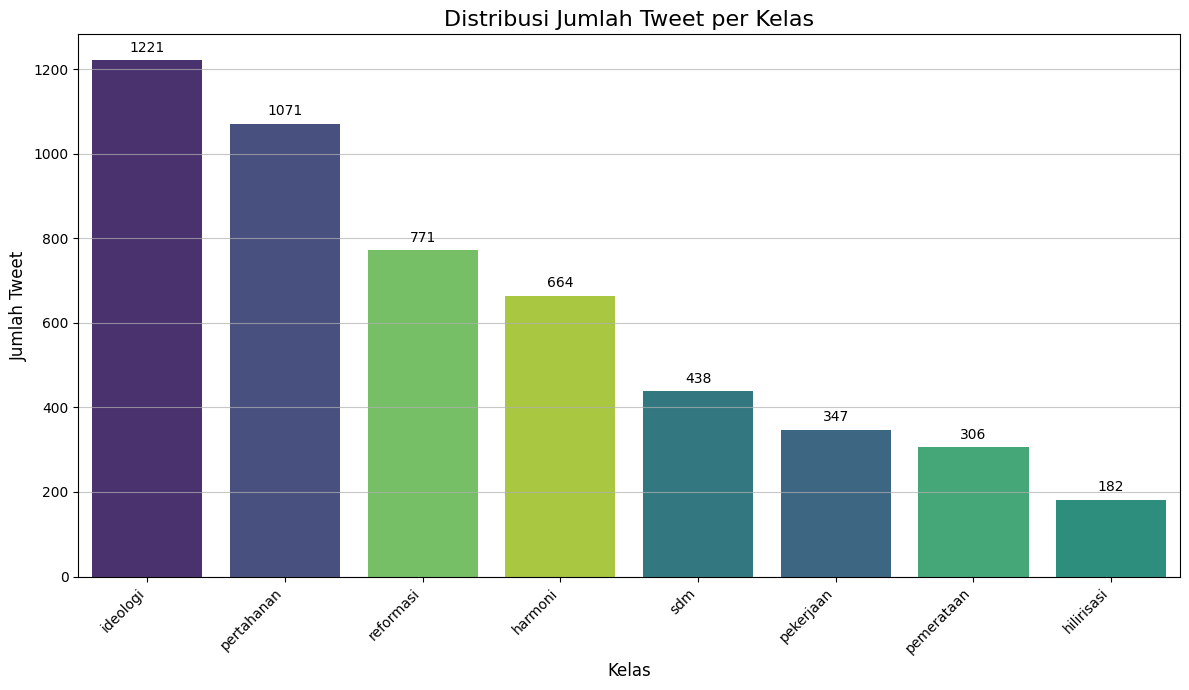

In [32]:
# Analisis Distribusi Kelas
plt.figure(figsize=(12, 7))
ax = sns.countplot(x=train_df['label'], order=train_df['label'].value_counts().index, hue=train_df['label'],palette='viridis', legend=False)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.title('Distribusi Jumlah Tweet per Kelas', fontsize=16)
plt.xlabel('Kelas', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()


**Insight :**
> Dataset di dominasi oleh kelas ideologi dan pertahanan, sedangkan kelas hilirasasi hanya mempunyai 182 baris dataset. Sehingga perlu perhatian khusus untuk kelas minoritas ini  

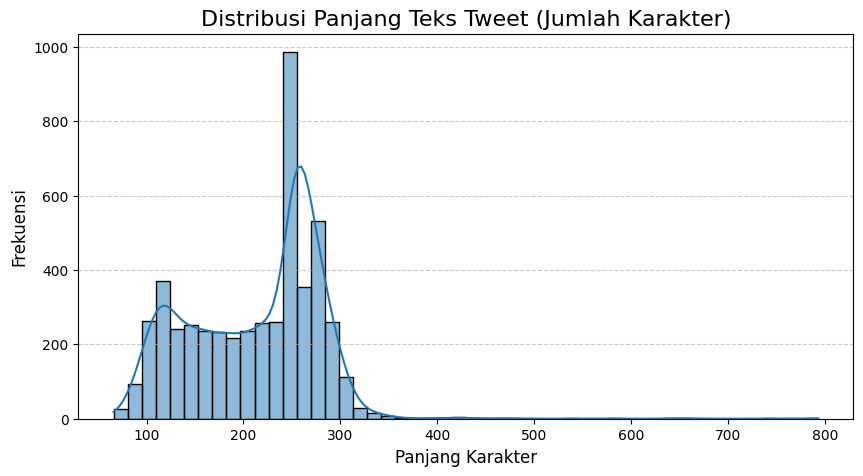

In [35]:
# Analisis Panjang Teks
train_df['text_length'] = train_df['text'].str.len()
plt.figure(figsize=(10, 5))
sns.histplot(train_df['text_length'], bins=50, kde=True)
plt.title('Distribusi Panjang Teks Tweet (Jumlah Karakter)', fontsize=16)
plt.xlabel('Panjang Karakter', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight:**
> Ditemukan baris data dengan panjang karakter hampir 1000 jumlah kata, sehingga perlu dilakukan pengecekan.  

Word Cloud berhasil dibuat.


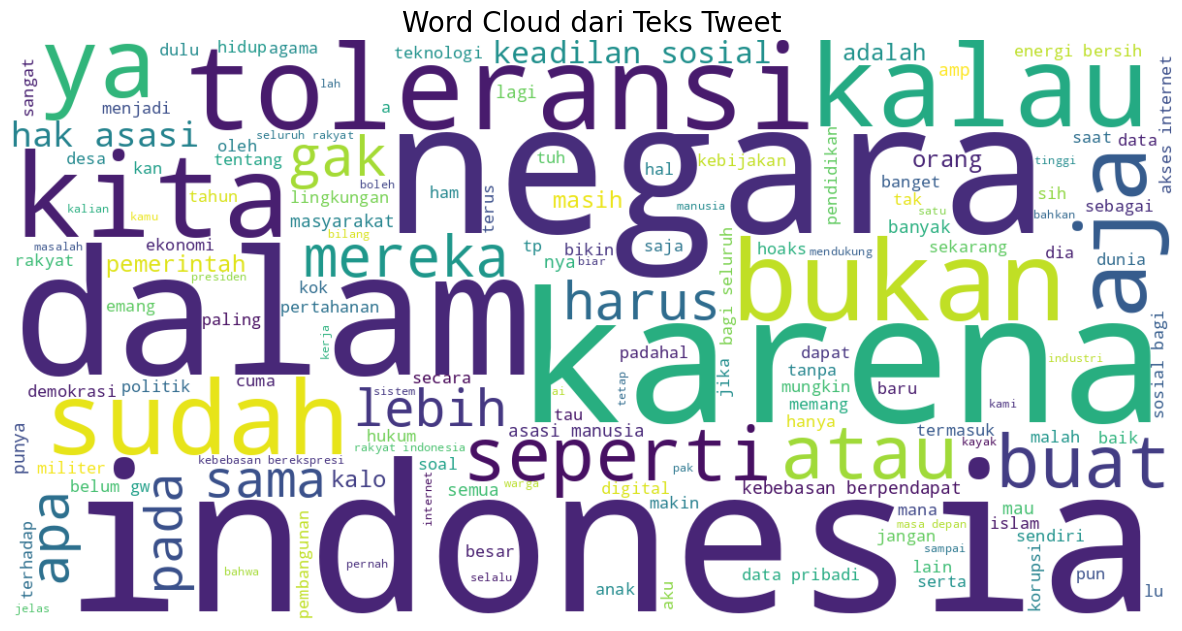

In [43]:
# Membuat Visualisasi Word Cloud

all_text = " ".join(tweet for tweet in train_df['clean_text'])

# Definisikan stopwords (kata-kata umum yang ingin diabaikan)
stopwords = set([
    "di", "dan", "yang", "ini", "itu", "ke", "dengan", "untuk", "dari",
    "tidak", "ada", "bisa", "jadi", "juga", "saya", "tapi", "akan", "para"])

# membuat objek WordCloud
wordcloud = WordCloud(width=1200, height=600, background_color="white",stopwords=stopwords,max_words=150,colormap='viridis',contour_width=3,contour_color='steelblue' ).generate(all_text)

# 4. Tampilkan gambar yang dihasilkan
print("Word Cloud berhasil dibuat.")
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud dari Teks Tweet", fontsize=20)
plt.show()

**Insight:**
> Kata-kata berukuran besar merupakan kata yang sering muncul dalam dataset seperti : indonesia, negara, tolerasi dan lainnya.

### **5. Preprocessing Data**
Berdasarkan temuan dari EDA, kita tahu bahwa data tweet mengandung banyak "noise" seperti URL, mention, emoji, dan slang. Tahap ini bertujuan untuk membersihkan noise tersebut dan menormalisasi teks ke dalam format yang lebih standar dan bersih. Prosesnya mencakup:

* Konversi teks ke huruf kecil.
* Menghapus URL, mention, dan emoji.
* Menghapus semua karakter non-alfanumerik.
* Menormalisasi kata-kata slang umum ke dalam Bahasa Indonesia baku menggunakan kamus yang telah kita susun.

In [5]:
# Definisikan kamus slang
slang_dict = {
    "gk": "tidak", "ga": "tidak", "bgt": "banget", "yg": "yang",
    "dr": "dari", "tdk": "tidak", "sy": "saya", "sbgai": "sebagai",
    "sbg": "sebagai", "ijasah": "ijazah", "jgn" : "jangan", 'jg': 'juga',
    'krn': 'karena', 'skr' : 'sekarang', 'nggak': 'tidak', "dgn": "dengan",
    "utk": "untuk", "dlm": "dalam", "klo": "kalau", "udah": "sudah",
    "blm": "belum"
}

# Definisikan fungsi pembersihan
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www.\S+", "", text)  # Hapus URL
    text = re.sub(r"@\w+", "", text)  # Hapus mention
    text = emoji.replace_emoji(text, replace="")  # Hapus emoji
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)  # Hapus tanda baca
    text = " ".join([slang_dict.get(word, word) for word in text.split()])  # Normalisasi slang
    text = re.sub(r'\s+', ' ', text).strip() # Hapus spasi berlebih
    return text

# Terapkan fungsi untuk membuat kolom baru 'clean_text'
train_df['clean_text'] = train_df['text'].apply(clean_tweet)
test_df['clean_text'] = test_df['text'].apply(clean_tweet)

print("\nKolom 'clean_text' berhasil dibuat.")
print("Verifikasi dengan menampilkan 5 baris pertama:")

# Tampilkan perbandingan untuk memastikan kolom sudah ada
display(train_df[['text', 'clean_text']].head())


Kolom 'clean_text' berhasil dibuat.
Verifikasi dengan menampilkan 5 baris pertama:


,text,clean_text
0,@hyalfay @NatharElyas @BosPurwa @NatharElyas @...,prabowo menang di 2024 karena strategi cerdas ...
1,@sienchao @Sherly0ctaviany @jokowi Halo @Sienc...,halo mungkin terus mengangkat isu negatif joko...
2,@giovannikurnwn @BudiBukanIntel Nama Budi Berl...,nama budi berlari mungkin mencerminkan sikap k...
3,@LeotardosMy @easyanying Kita akui keberhasila...,kita akui keberhasilannya kita akui juga kekur...
4,@LuckyGaben @susipudjiastuti @prabowo Indonesi...,indonesia masih bisa menuju kesuksesan tapi ru...


## **6. Data Splitting**

Setelah data teks dibersihkan, langkah selanjutnya adalah membagi data latih menjadi dua bagian terpisah:

1.  **Training Set (80%):** Kumpulan data yang akan digunakan untuk "mengajari" model.
2.  **Validation Set (20%):** Kumpulan data yang disisihkan untuk menguji dan mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya. Ini penting untuk memantau *overfitting*.

Untuk memastikan reproduktifitas code, digunakanlah seed(42)

In [7]:
# Tentukan fitur (X) dan target (y) dari DataFrame utama
X = train_df['clean_text']
y = train_df['label']

# Lakukan pembagian data 80:20
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% untuk data validasi
    random_state=42,     # Seed untuk reproduktifitas
    stratify=y           # Menjaga proporsi kelas
)

print("Pembagian data selesai.")
print(f"Ukuran data latih (X_train): {X_train.shape[0]} sampel")
print(f"Ukuran data validasi (X_val): {X_val.shape[0]} sampel")

# Verifikasi proporsi kelas (opsional tapi praktik yang baik)
print("\nProporsi kelas di set data latih (y_train):")
print(y_train.value_counts(normalize=True).sort_index())

Pembagian data selesai.
Ukuran data latih (X_train): 4000 sampel
Ukuran data validasi (X_val): 1000 sampel

Proporsi kelas di set data latih (y_train):
label
harmoni       0.13275
hilirisasi    0.03625
ideologi      0.24425
pekerjaan     0.06950
pemerataan    0.06125
pertahanan    0.21425
reformasi     0.15425
sdm           0.08750
Name: proportion, dtype: float64


## **7. Model Baseline (TF-IDF + Random Forest)**

Sebelum menggunakan model Transformer yang kompleks, penting untuk menetapkan performa dasar (*baseline*) menggunakan pendekatan *machine learning* klasik. Ini memberi kita tolok ukur yang jelas untuk mengukur nilai tambah dari model yang lebih canggih.

**Metodologi Baseline:**
* Menggunakan TF-IDF (Term Frequency-Inverse Document Frequency) untuk mengubah data teks menjadi representasi numerik berdasarkan frekuensi dan keunikan kata.
* Menggunakan Random Forest, sebuah model *ensemble* yang kuat dan cepat dilatih.
* Performa akan diukur menggunakan Balanced Accuracy pada *validation set*.

In [8]:
# Buat pipeline yang menggabungkan TF-IDF dan Random Forest
pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words=['di', 'dan', 'yang', 'ini', 'itu'])),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1))
])

# Latih pipeline pada data latih yang sudah dibagi
pipeline_rf.fit(X_train, y_train)

# Lakukan prediksi pada data validasi
y_pred_base = pipeline_rf.predict(X_val)

# Evaluasi performa model baseline
baseline_score_rf = balanced_accuracy_score(y_val, y_pred_base)

print(f"\nSkor Balanced Accuracy Baseline (TF-IDF + Random Forest): {baseline_score_rf:.4f}")

Memulai pelatihan model baseline TF-IDF + Random Forest...

Skor Balanced Accuracy Baseline (TF-IDF + Random Forest): 0.4745


**Hasil Baseline:**
> Model *baseline* klasik ini mencapai skor `Balanced Accuracy` sekitar **0.4745**. Skor ini menjadi tolok ukur fundamental yang harus kita kalahkan dengan pendekatan *deep learning* menggunakan IndoBERT di tahap selanjutnya.

## **8. Model Utama: IndoBERT dengan K-Fold Ensemble**

Setelah kita beralih ke pendekatan *deep learning* yang lebih canggih untuk melampaui *baseline* tersebut. Strategi utama kami dibangun di atas beberapa pilar:

* **Arsitektur Model:** Menggunakan **`indobenchmark/indobert-base-p2`**, sebuah model Transformer yang telah dioptimalkan secara spesifik untuk Bahasa Indonesia.
* **Strategi Validasi:** Menerapkan **Stratified K-Fold (5-Fold)** untuk melatih 5 model pada subset data yang berbeda. Ini memastikan evaluasi performa yang stabil dan mengurangi risiko *overfitting* pada satu *data split*
* **Penanganan *Imbalance*:** Menggunakan **Class Weights** pada *loss function* untuk "memaksa" model memberi perhatian lebih pada kelas-kelas minoritas, yang sangat krusial untuk metrik *Balanced Accuracy*.
* **Pencegahan *Overfitting*:** Mengaktifkan mekanisme **Early Stopping** (`load_best_model_at_end`) untuk secara otomatis memilih versi model dari *epoch* dengan performa validasi terbaik di setiap *fold*.

In [17]:
# --- Persiapan Komponen ---
MODEL_NAME = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
def tokenize(batch): return tokenizer(batch["clean_text"], truncation=True)

# Definisikan label_map dan pastikan train_df memiliki label_id
labels = sorted(train_df['label'].unique())
label_map = {label: i for i, label in enumerate(labels)}
train_df['label_id'] = train_df['label'].map(label_map)

class WeightedTrainer(Trainer):
    def __init__(self, *args, **kwargs):
        self.custom_class_weights = kwargs.pop('class_weights', None)
        super().__init__(*args, **kwargs)
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels"); outputs = model(**inputs)
        logits = outputs.get("logits"); weights = self.custom_class_weights.to(model.device)
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {'balanced_accuracy': balanced_accuracy_score(labels, predictions)}

print("Komponen untuk pipeline utama telah siap.")

# --- Pelatihan K-Fold ---
# (Tokenisasi test_df di sini karena tidak berubah di dalam loop)
test_dataset_tokenized = Dataset.from_pandas(test_df[['clean_text']]).map(tokenize, batched=True)

# Hitung class weights menggunakan kolom numerik 'label_id'
class_counts = train_df['label_id'].value_counts().sort_index()
class_weights = torch.tensor(len(train_df) / (len(label_map) * class_counts), dtype=torch.float)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
preds_list = []
oof_preds, oof_true, oof_indices = [], [], []

# Proses split
for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['label_id'])):
    print(f"\n===== FOLD {fold+1} / 5 =====")
    train_data = train_df.iloc[train_idx]
    val_data = train_df.iloc[val_idx]

    # Gunakan 'label_id' saat membuat dataset, lalu ganti namanya menjadi 'labels'
    train_dataset = Dataset.from_pandas(train_data[['clean_text', 'label_id']]).map(tokenize, batched=True).rename_column("label_id", "labels")
    val_dataset = Dataset.from_pandas(val_data[['clean_text', 'label_id']]).map(tokenize, batched=True).rename_column("label_id", "labels")

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(label_map))

    training_args = TrainingArguments(
        output_dir=f"./results_fold_{fold+1}",
        eval_strategy="epoch", save_strategy="epoch", load_best_model_at_end=True,
        metric_for_best_model="eval_balanced_accuracy", greater_is_better=True,
        save_total_limit=1, learning_rate=2e-5, per_device_train_batch_size=16,
        num_train_epochs=4, weight_decay=0.01, logging_strategy="epoch", report_to="none"
    )

    trainer = WeightedTrainer(model=model, args=training_args, train_dataset=train_dataset,
                              eval_dataset=val_dataset, tokenizer=tokenizer,
                              data_collator=DataCollatorWithPadding(tokenizer),
                              class_weights=class_weights, compute_metrics=compute_metrics)

    trainer.train()

    val_score = trainer.evaluate(val_dataset)["eval_balanced_accuracy"]
    fold_scores.append(val_score)
    print(f"Balanced Accuracy Terbaik Fold {fold+1}: {val_score:.4f}")

    val_preds_raw = trainer.predict(val_dataset)
    oof_preds.extend(np.argmax(val_preds_raw.predictions, axis=1))
    oof_true.extend(val_preds_raw.label_ids)
    oof_indices.extend(val_idx)

    test_preds = trainer.predict(test_dataset_tokenized)
    preds_list.append(test_preds.predictions)

    del model, trainer; torch.cuda.empty_cache(); gc.collect()

print(f"\nPelatihan 5-Fold Selesai. Rata-rata Skor Validasi: {np.mean(fold_scores):.4f}")

Komponen untuk pipeline utama telah siap.


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



===== FOLD 1 / 5 =====


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3549322104.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Balanced Accuracy
1,1.554000,1.148657,0.550432
2,1.064200,1.121010,0.582140
3,0.770600,1.143083,0.596691
4,0.552800,1.190838,0.587901


Balanced Accuracy Terbaik Fold 5: 0.5967



Pelatihan 5-Fold Selesai. Rata-rata Skor Validasi: 0.5997


**Insight:**
> Model dengan akurasi tertinggi ialah model pada Fold ke-2 di epoch ke-2 dengan balance akurasi sebesar: **0.6247**. sedangkan rata-rata skor Balanced Accuracy sebesar **0.5997** 

## **9. Evaluasi dan Pembuatan Submission**

##### **Ensemble Prediksi dan Analisis Performa Gabungan**  
Menggabungkan prediksi dari kelima model pada data tes menggunakan metode **Weighted Average**, di mana model dengan performa validasi lebih tinggi akan diberi bobot lebih besar. Serta membuat *Classification Report* dan *Confusion Matrix* yang komprehensif.



 ANALISIS EVALUASI GABUNGAN 

--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

     harmoni       0.79      0.70      0.74       664
  hilirisasi       0.30      0.55      0.39       182
    ideologi       0.76      0.71      0.73      1221
   pekerjaan       0.45      0.46      0.45       347
  pemerataan       0.39      0.47      0.43       306
  pertahanan       0.84      0.81      0.82      1071
   reformasi       0.59      0.51      0.55       771
         sdm       0.50      0.59      0.54       438

    accuracy                           0.65      5000
   macro avg       0.58      0.60      0.58      5000
weighted avg       0.67      0.65      0.66      5000

--------------------------------------------------

--- Confusion Matrix ---


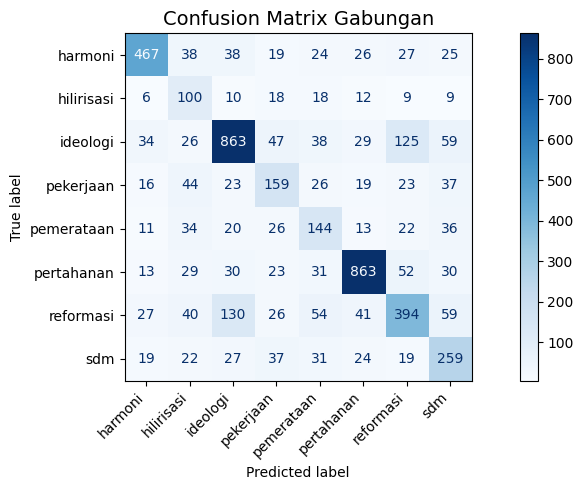

--------------------------------------------------


In [45]:
# --- 8a. Analisis Evaluasi Gabungan ---
print("\n ANALISIS EVALUASI GABUNGAN ")

# Susun kembali prediksi OOF agar urutannya sesuai dengan train_df asli
oof_df = pd.DataFrame({'index': oof_indices, 'true': oof_true, 'pred': oof_preds})
oof_df = oof_df.sort_values(by='index').reset_index(drop=True)
y_true_oof, y_pred_oof = oof_df['true'], oof_df['pred']

# Tampilkan Laporan Klasifikasi (tetap dalam format teks)
print("\n--- Laporan Klasifikasi ---")
print(classification_report(y_true_oof, y_pred_oof, target_names=labels))
print("-" * 50)

# --- Confusion Matrix ---
print("\n--- Confusion Matrix ---")
fig, ax = plt.subplots(figsize=(10, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_true_oof,
    y_pred_oof,
    display_labels=labels,
    cmap=plt.cm.Blues,
    ax=ax
)
ax.set_title("Confusion Matrix Gabungan", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print("-" * 50)

**Insight:**
> Berdasarkan Laporan Klasifikasi, model mampu memprediksi kelas pertahanan dan harmoni. Hal ini bisa dilihat dari f1-score keduanya berturut-turut sebesar 0.82 dan 0.74.
Sedangkan untuk kelas hilirisasi model kesulitan untuk memprediksinya.

#### **Membuat File Submission**

In [47]:
# --- 8b. Ensemble dan Pembuatan Submission ---
print("\n" + "="*20 + " PEMBUATAN FILE SUBMISSION " + "="*20)

weights = np.array(fold_scores)
normalized_weights = weights / np.sum(weights)
print(f"Bobot yang digunakan untuk ensemble: {np.round(normalized_weights, 4)}")

avg_preds = np.sum(np.array(preds_list) * normalized_weights[:, np.newaxis, np.newaxis], axis=0)
final_preds = np.argmax(avg_preds, axis=1)

inv_label_map = {v: k for k, v in label_map.items()}
final_labels = [inv_label_map[i] for i in final_preds]

submission = pd.DataFrame({"id": test_df["id"], "label": final_labels})
submission.to_csv("submission_final.csv", index=False)

print("\nFile submission_final.csv berhasil dibuat.")


==================== PEMBUATAN FILE SUBMISSION ====================
Bobot yang digunakan untuk ensemble: [0.2002 0.2083 0.1933 0.1992 0.199 ]

File submission_final.csv berhasil dibuat.


> Hasil *ensemble* akan digunakan untuk membuat file `submission.csv` final.

## **10. Kesimpulan dan Rekomendasi Strategis**

#### Kesimpulan
Proyek ini berhasil mengembangkan sebuah *pipeline machine learning* yang *robust* untuk memetakan dan menganalisis wacana publik di platform X terkait delapan pilar Astacita. Melalui serangkaian eksperimen yang sistematis, model final berhasil melampaui performa *baseline* secara signifikan dan mampu memberikan gambaran kuantitatif mengenai fokus sentimen masyarakat.

**A. Pencapaian Teknis dan Performa Model**
1.  **Performa Model:** Model *baseline* klasik (TF-IDF + Random Forest) mencapai skor *Balanced Accuracy* sebesar **0.4745**. Model utama yang dioptimalkan, menggunakan *ensemble* 5-Fold dari `indobenchmark/indobert-base-p2`, berhasil mencapai skor validasi rata-rata **0.5997** dan skor akhir di *leaderboard* sebesar **[Masukkan skor Kaggle terbaik Anda]**.
2.  **Efektivitas Metodologi:** Pendekatan yang paling efektif terbukti adalah kombinasi dari **pra-pemrosesan teks yang cermat**, penggunaan **Class Weights** untuk menangani data tidak seimbang, validasi silang dengan **Stratified K-Fold**, dan mekanisme **Early Stopping** untuk mencegah *overfitting*.
3.  **Analisis Kekuatan & Kelemahan:** Berdasarkan *Classification Report* dan *Confusion Matrix*, model menunjukkan performa **sangat baik** pada kelas mayoritas seperti `pertahanan` (F1-score 0.82) dan `harmoni` (F1-score 0.74). Namun, model menghadapi **tantangan signifikan** pada kelas minoritas seperti `hilirisasi` (F1-score 0.36) dan kesulitan membedakan kelas yang tumpang tindih, terutama antara `ideologi` dan `reformasi`.

**B. Insight Strategis dari Wacana Publik**
1.  **Fokus Wacana Publik:** Analisis menunjukkan bahwa pilar **`ideologi`** dan **`pertahanan`** menjadi topik yang paling dominan dan sering didiskusikan oleh publik. Sebaliknya, pilar yang bersifat lebih teknis-ekonomi seperti **`hilirisasi`** dan **`pemerataan`** memiliki volume diskusi yang jauh lebih rendah.
2.  **Ambiguitas Konseptual di Mata Publik:** Ditemukan adanya tumpang tindih makna yang signifikan antara pilar **`reformasi`** dan **`ideologi`**. Publik seringkali membahas isu-isu reformasi (seperti pemberantasan korupsi) dalam kerangka ideologi dan kesehatan demokrasi, menunjukkan bahwa kedua konsep ini tidak dapat dipisahkan dalam komunikasi publik.
3.  **Kreativitas Solusi yang Ditawarkan:** Inovasi utama dari proyek ini adalah kemampuannya untuk **mengubah "noise" dari jutaan percakapan tidak terstruktur di media sosial menjadi *insight* strategis yang terukur**. *Pipeline* ini berfungsi sebagai jembatan analitis antara suara publik dengan perumusan kebijakan, memungkinkan pemerintah untuk tidak hanya mendengar, tetapi juga memahami dinamika wacana publik secara *real-time*.

#### **Rekomendasi Strategis untuk Pemerintah**
Berdasarkan temuan di atas, berikut adalah beberapa rekomendasi strategis yang dapat ditindaklanjuti:
1.  **Tingkatkan Sosialisasi dan Edukasi Pilar Ekonomi Digital:** Rendahnya volume diskusi publik mengenai **`hilirisasi`** dan **`pemerataan`** menandakan adanya "kesenjangan komunikasi". Direkomendasikan untuk merancang kampanye komunikasi yang lebih terfokus untuk menjelaskan relevansi dan dampak kedua pilar ini terhadap masyarakat.
2.  **Integrasikan Narasi Komunikasi `Reformasi` dan `Ideologi`:** Mengingat publik melihat hubungan yang erat antara keduanya, disarankan agar program komunikasi pemerintah tidak memisahkan isu pemberantasan korupsi (`reformasi`) dari narasi penguatan ideologi bangsa (`ideologi`). Upaya reformasi dapat dibingkai sebagai langkah konkret untuk mewujudkan nilai-nilai Pancasila.
3.  **Manfaatkan Model sebagai Dasbor Sentimen Publik:** *Pipeline* yang telah dibangun ini dapat dioperasionalkan menjadi sebuah **"dasbor sentimen publik"** *real-time* untuk memantau isu yang sedang tren, mengukur efektivitas kampanye, dan mendeteksi disinformasi secara dini.